<a href="https://colab.research.google.com/github/ERIC01205/YTP_PRACTICE/blob/main/Class02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tensor

In [ ]:
import torch

# 手動建立一個 3x2 的 2D Tensor
# 每一列 (row) 代表一個學生，每一欄 (column) 代表一個科目
grades_2d = torch.tensor([
    [85.3, 92.2],
    [70.6, 65.2],
    [99.1, 88.6]
])

print("--- 2D Tensor (3x2) ---")
print(grades_2d)
print(f"維度 (ndimension): {grades_2d.ndimension()}") # 會顯示 2
print(f"形狀 (shape): {grades_2d.shape}")             # 會顯示 [3, 2]

--- 2D Tensor (3x2) ---
tensor([[85.3000, 92.2000],
        [70.6000, 65.2000],
        [99.1000, 88.6000]])
維度 (ndimension): 2
形狀 (shape): torch.Size([3, 2])


In [ ]:
# 手動建立一個 2x3x2 的 3D Tensor
# 結構：[班級數, 學生數, 科目數]
school_3d = torch.tensor([
    [ # 第一班
        [85.0, 92.0],
        [70.0, 65.0],
        [99.0, 88.0]
    ],
    [ # 第二班
        [60.0, 72.0],
        [88.0, 81.0],
        [75.0, 90.0]
    ]
])

print("\n--- 3D Tensor (2x3x2) ---")
print(school_3d)
print(f"維度 (ndimension): {school_3d.ndimension()}") # 會顯示 3
print(f"形狀 (shape): {school_3d.shape}")       # torch.Size([2, 3, 2])


--- 3D Tensor (2x3x2) ---
tensor([[[85., 92.],
         [70., 65.],
         [99., 88.]],

        [[60., 72.],
         [88., 81.],
         [75., 90.]]])
維度 (ndimension): 3
形狀 (shape): torch.Size([2, 3, 2])


# GPU

In [ ]:
# 檢查是否有 GPU (CUDA)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"目前使用的設備是: {device}")

# 建立一個 Tensor 預設是在 CPU 上
x = torch.ones(3, 3)

# 移動到 GPU
x_gpu = x.to(device)

print(f"x 的位置: {x.device}")
print(f"x_gpu 的位置: {x_gpu.device}")

目前使用的設備是: cuda
x 的位置: cpu
x_gpu 的位置: cuda:0


# Autograd

In [ ]:
import torch

# 建立一個張量並開啟梯度追蹤
x = torch.tensor(3.0, requires_grad=True)

# 定義一個函數 y = 3x^2 + 4x + 5
y = 3*x**2 + 4*x + 5

print(f"x 的值: {x}")
print(f"y 的計算結果: {y}") # y = 3(9) + 4(3) + 5 = 44

x 的值: 3.0
y 的計算結果: 44.0


In [ ]:
# 呼叫 backward() 開始自動微分
y.backward(retain_graph=True)

# 查看 x 的梯度 (Gradient)
print(f"PyTorch 算出的梯度 (dy/dx): {x.grad}")

PyTorch 算出的梯度 (dy/dx): 22.0


In [ ]:
# 模擬兩次運算
for i in range(2):
    y = x**2
    y.backward()
    print(f"第 {i+1} 次運算後的 x.grad: {x.grad}")

    # 如果不手動歸零，第二次會變 6 + 6 = 12
    # 在訓練模型時，我們必須執行：
    # x.grad.zero_()

第 1 次運算後的 x.grad: 76.0
第 2 次運算後的 x.grad: 82.0


# Toy Eaxmple

In [ ]:
import torch
import torch.nn as nn
# toy example
x = torch.tensor([[1,-1], [2,3], [5,2]], dtype=torch.float32) # 3x2
y = torch.tensor([[1],[0],[1]], dtype=torch.float32)

w1 = torch.rand(2,3, requires_grad=True)
w2 = torch.rand(3,3, requires_grad=True)
w3 = torch.rand(3,2, requires_grad=True)
w4 = torch.rand(2,1, requires_grad=True)
relu = nn.ReLU()
sigmoid = nn.Sigmoid()
bce = nn.BCELoss()

def forward(inputs):
    inputs = torch.matmul(inputs, w1)
    inputs = relu(inputs)
    inputs = torch.matmul(inputs, w2)
    inputs = relu(inputs)
    inputs = torch.matmul(inputs, w3)
    inputs = relu(inputs)
    inputs = torch.matmul(inputs, w4)
    outputs = sigmoid(inputs)
    return outputs

# loss
def loss(y_true, y_pred):
    return bce(y_pred, y_true)


learning_rate = 0.01
epochs = 10

for epoch in range(epochs):
    # forward pass
    y_hat = forward(inputs=x)

    # loss
    bce_loss = loss(y_true=y, y_pred=y_hat)

    # backward loss
    bce_loss.backward()

    # update weights
    with torch.no_grad():
        w1 -= learning_rate * w1.grad
        w2 -= learning_rate * w2.grad
        w3 -= learning_rate * w3.grad
        w4 -= learning_rate * w4.grad

    # zero gradients
    w1.grad.zero_()
    w2.grad.zero_()
    w3.grad.zero_()
    w4.grad.zero_()


    print(f"epoch {epoch + 1}: \nw1 = {w1}\n w2 = {w2}\n w3 = {w3}\n w4 = {w4}, loss = {bce_loss:.8f}")

epoch 1: 
w1 = tensor([[0.9546, 0.5284, 0.9884],
        [0.1751, 0.5764, 0.5440]], requires_grad=True)
 w2 = tensor([[0.1863, 0.3148, 0.3370],
        [0.3352, 0.0806, 0.8847],
        [0.4852, 0.4227, 0.9640]], requires_grad=True)
 w3 = tensor([[0.8088, 0.7300],
        [0.3710, 0.5567],
        [0.8754, 0.8489]], requires_grad=True)
 w4 = tensor([[0.0239],
        [0.2869]], requires_grad=True), loss = 1.36162663
epoch 2: 
w1 = tensor([[0.9538, 0.5264, 0.9863],
        [0.1731, 0.5734, 0.5393]], requires_grad=True)
 w2 = tensor([[0.1848, 0.3137, 0.3353],
        [0.3332, 0.0792, 0.8824],
        [0.4828, 0.4210, 0.9612]], requires_grad=True)
 w3 = tensor([[0.8086, 0.7273],
        [0.3708, 0.5546],
        [0.8749, 0.8431]], requires_grad=True)
 w4 = tensor([[-0.0039],
        [ 0.2590]], requires_grad=True), loss = 1.17657530
epoch 3: 
w1 = tensor([[0.9531, 0.5248, 0.9847],
        [0.1715, 0.5710, 0.5355]], requires_grad=True)
 w2 = tensor([[0.1837, 0.3129, 0.3340],
        [0.331

# Dataset & Dataloader

In [ ]:
from torch.utils.data import Dataset, DataLoader

class ScoreDataset(Dataset):
  def __init__(self):
    self.x = torch.tensor([[1,2,3],[4,5,6],[7,8,9],[10,11,12],[13,14,15],[16,17,18]]) # 6x3
    self.y = torch.tensor([[1],[0],[1],[1],[1],[0]]) # 6x1

  def __getitem__(self,index):
    return self.x[index], self.y[index]

  def __len__(self):
    return self.x.size(0)

In [ ]:
score_dataset = ScoreDataset()
print(score_dataset.x)
print(score_dataset.y)

tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12],
        [13, 14, 15],
        [16, 17, 18]])
tensor([[1],
        [0],
        [1],
        [1],
        [1],
        [0]])


In [ ]:
dataLoader = DataLoader(dataset=score_dataset,batch_size=2,shuffle=True)
for i, (x,y) in enumerate(dataLoader):
  print(f"{i}: x={x}, y={y}")

0: x=tensor([[ 7,  8,  9],
        [10, 11, 12]]), y=tensor([[1],
        [1]])
1: x=tensor([[16, 17, 18],
        [ 4,  5,  6]]), y=tensor([[0],
        [0]])
2: x=tensor([[13, 14, 15],
        [ 1,  2,  3]]), y=tensor([[1],
        [1]])


# Computer vision

In [ ]:
import cv2 # opencv
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/YTP/demo-1.jpg"
image = cv2.imread(path)
print(type(image))
print(image.shape) # h, w, c
print(image)

<class 'numpy.ndarray'>
(2267, 3400, 3)
[[[140 159 167]
  [140 159 167]
  [141 160 168]
  ...
  [161 179 186]
  [161 179 186]
  [162 180 187]]

 [[140 159 167]
  [140 159 167]
  [141 160 168]
  ...
  [162 180 187]
  [162 180 187]
  [162 180 187]]

 [[140 159 167]
  [140 159 167]
  [141 160 168]
  ...
  [162 180 187]
  [162 180 187]
  [163 181 188]]

 ...

 [[140 157 170]
  [140 157 170]
  [140 157 170]
  ...
  [192 201 204]
  [192 201 204]
  [191 200 203]]

 [[140 157 170]
  [140 157 170]
  [140 157 170]
  ...
  [192 201 204]
  [192 201 204]
  [191 200 203]]

 [[140 157 170]
  [140 157 170]
  [140 157 170]
  ...
  [192 201 204]
  [192 201 204]
  [191 200 203]]]


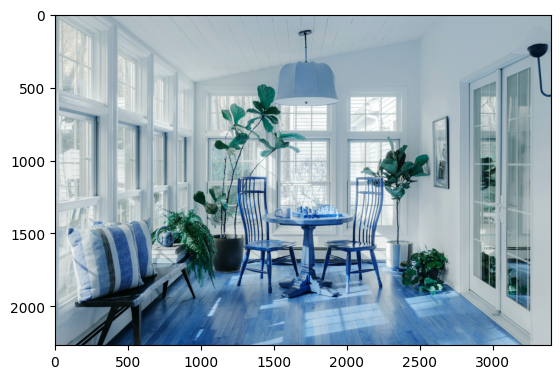

In [ ]:
plt.imshow(image) # cv2 (B, G, R)
plt.show()

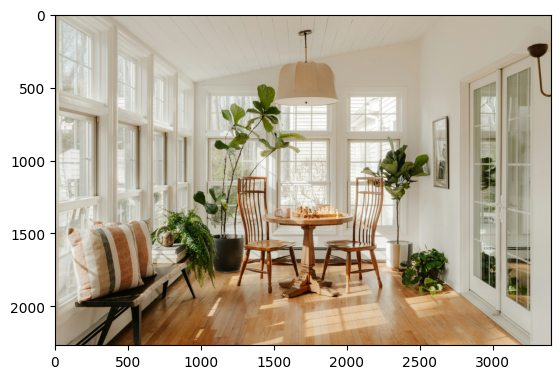

In [ ]:
new_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(new_image)
plt.show()

# Feed Forward Neural Network (Fully connected Neural Network)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.60MB/s]


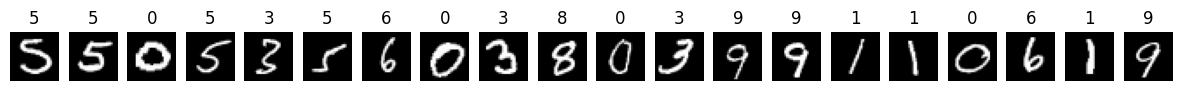

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt


# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# hyperparamter
BATCH_SIZE = 64
num_classes = 10
epochs = 10
learning_rate = 1e-4 # 0.0001

# Dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor(), download=True)


train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size = BATCH_SIZE, shuffle = False)


data_iter = iter(train_loader)
images, labels = next(data_iter)

# 開始畫圖
fig, axes = plt.subplots(1, 20, figsize=(15, 3)) # 調整一下 figsize 高度比較美觀
for i in range(20):
    # images[i][0] 是因為 MNIST 是黑白圖，shape 是 [Batch, Channel, H, W]
    # 取出第 i 張圖的第 0 個 Channel
    axes[i].imshow(images[i][0], cmap='gray')
    axes[i].set_title(labels[i].item()) # 順便把正確答案(標籤)印出來
    axes[i].axis('off')

plt.show()

In [ ]:
# Model
class Net(nn.Module):
  def __init__(self, input_size, h1, h2, num_classes):
    super().__init__()
    self.f1 = nn.Linear(input_size, h1)
    self.f2 = nn.Linear(h1, h2)
    self.f3 = nn.Linear(h2, num_classes)

  def forward(self, x):
    x = F.relu(self.f1(x))
    x = F.relu(self.f2(x))
    out = self.f3(x)
    return out

In [ ]:
input_size = 784
h1 = 256
h2 = 128
net = Net(input_size=input_size, h1=h1, h2=h2, num_classes=num_classes).to(device) # GPU

In [ ]:
[p.numel() for p in net.parameters() if p.requires_grad]

[200704, 256, 32768, 128, 1280, 10]

In [ ]:
# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)

In [ ]:
from tqdm import tqdm

# 取得 GPU 狀態的輔助函式
def get_gpu_memory():
    if torch.cuda.is_available():
        # 回傳已使用的顯存 (單位：GB)
        return torch.cuda.memory_allocated() / 1024**3
    return 0

# training loop
total_steps = len(train_loader)

for epoch in range(epochs):
    # 使用 leave=True 讓每個 Epoch 的紀錄都留著
    pbar = tqdm(enumerate(train_loader), total=total_steps, desc=f'Epoch {epoch+1}/{epochs}', leave=True)

    for i, (images, labels) in pbar:
        images = images.view(-1, 28*28).to(device)
        labels = labels.to(device)

        # Forward & Backward
        outputs = net(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 每 10 步更新一次進度條，同時顯示 Loss 和 GPU 佔用量
        if (i+1) % 10 == 0:
            gpu_mem = get_gpu_memory()
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'GPU_Used': f'{gpu_mem:.2f}GB'
            })

print("全部訓練完成！")

Epoch 10/10: 100%|██████████| 938/938 [00:09<00:00, 98.16it/s, Loss=0.0573, GPU_Used=0.02GB] 

全部訓練完成！


In [ ]:
# test
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    for images, labels in test_loader:
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)
        outputs = net(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()
    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network on the 10000 test images: {acc} %')

Accuracy of the network on the 10000 test images: 96.69 %


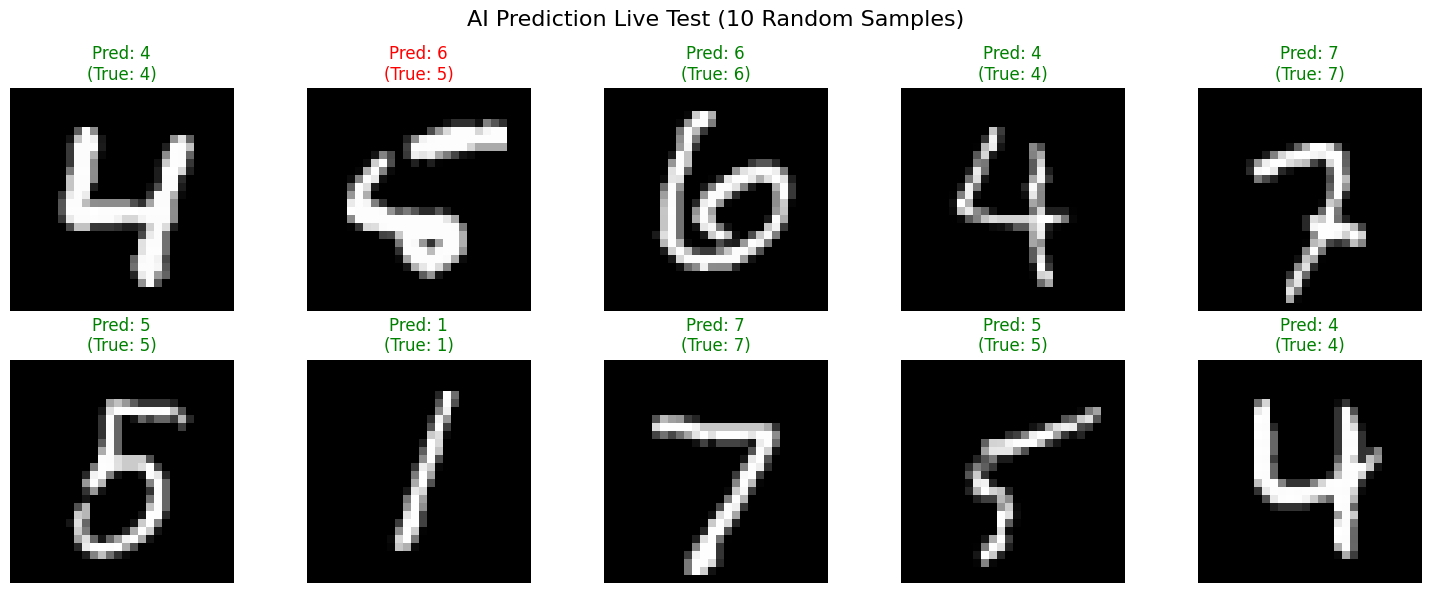

In [ ]:
import matplotlib.pyplot as plt
import random

# Switch to evaluation mode
net.eval()

# Get one batch of data from the test_loader
data_iter = iter(test_loader)
images, labels = next(data_iter)

# Randomly select 10 indices from this batch
random_indices = random.sample(range(len(images)), 10)

plt.figure(figsize=(15, 6))
plt.suptitle("AI Prediction Live Test (10 Random Samples)", fontsize=16)

with torch.no_grad():
    for i, idx in enumerate(random_indices):
        # 1. Prepare data
        img = images[idx].to(device)
        label = labels[idx].item()

        # 2. Model prediction (reshape to match input layer)
        output = net(img.view(-1, 28*28))
        _, predicted = torch.max(output, 1)
        pred_idx = predicted.item()

        # 3. Visualization
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[idx].squeeze(), cmap='gray')

        # Use Green for correct, Red for incorrect
        color = 'green' if pred_idx == label else 'red'
        plt.title(f"Pred: {pred_idx}\n(True: {label})", color=color)
        plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()